Function: compute window-level vibration features and save a feature table.

Feature strategy:
1. Load window metadata and filtered IMU signals,
2. Reconstruct each window by run_id and time range,
3. Remove per-window accelerometer DC/gravity offset (ax, ay, az) via window-wise mean subtraction,
4. Compute time-domain features (mean, std, RMS, peak-to-peak, energy, mean absolute value),
5. Compute frequency-band powers (1-5 Hz, 5-20 Hz, 20-40 Hz),
6. Add impact and dynamics features: per-axis kurtosis (ax, ay, az), per-axis jerk RMS from normalized acceleration, and detrended ay RMS/std,
7. Save engineered features to data/processed/window_features.csv.

The output excludes raw sample sequences and is ready for analysis/modeling.

In [1]:
from pathlib import Path
import sys

import pandas as pd

# Make project root importable whether CWD is repo root or notebooks/
cwd = Path.cwd()
PROJECT_ROOT = cwd if (cwd / 'src').exists() else cwd.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.features import compute_window_features

SAMPLE_RATE = 100  # Hz
ACC_COLS = ['ax', 'ay', 'az']
GYRO_COLS = ['gx', 'gy', 'gz']
IMU_COLS = ACC_COLS + GYRO_COLS

filtered_path = PROJECT_ROOT / 'data' / 'interim' / 'filtered' / 'filtered_dataset.csv'
cleaned_path = PROJECT_ROOT / 'data' / 'interim' / 'cleaned' / 'cleaned_dataset.csv'
windows_path = PROJECT_ROOT / 'data' / 'processed' / 'windowed_metadata.csv'

if filtered_path.exists():
    signal_path = filtered_path
    print('Using filtered dataset for feature extraction')
elif cleaned_path.exists():
    signal_path = cleaned_path
    print('Filtered dataset not found; using cleaned dataset')
else:
    raise FileNotFoundError('No source dataset found. Run 04_cleaning.ipynb and 04b_filtering.ipynb first.')

if not windows_path.exists():
    raise FileNotFoundError(f'Window metadata not found: {windows_path}. Run 05_windowing.ipynb first.')

signals_df = pd.read_csv(signal_path, low_memory=False)
windows_df = pd.read_csv(windows_path, low_memory=False)

missing_imu = [c for c in IMU_COLS if c not in signals_df.columns]
if missing_imu:
    raise KeyError(f'Missing IMU columns in source dataset: {missing_imu}')

required_signal_cols = ['run_id', 't_rel', 'label']
missing_required = [c for c in required_signal_cols if c not in signals_df.columns]
if missing_required:
    raise KeyError(f'Missing required columns in source dataset: {missing_required}')

signals_df = signals_df.sort_values(['run_id', 't_rel']).reset_index(drop=True)

print(f'Signals source: {signal_path}')
print(f'Signals shape: {signals_df.shape}')
print(f'Window metadata shape: {windows_df.shape}')
print('Accelerometer normalization: per-window mean subtraction on ax/ay/az')

features_df = compute_window_features(
    windows_df=windows_df,
    signals_df=signals_df,
    sample_rate=SAMPLE_RATE,
)

if features_df.empty:
    raise RuntimeError('No features were generated. Check window metadata and source signals.')

id_cols = ['window_id', 'run_id', 'segment_id', 'label', 't_start', 't_end', 'n_samples']
feature_cols = [c for c in features_df.columns if c not in id_cols]
features_df = features_df[id_cols + feature_cols]

new_feature_cols = [
    'ax_kurtosis', 'ay_kurtosis', 'az_kurtosis',
    'ax_jerk_rms', 'ay_jerk_rms', 'az_jerk_rms',
    'ay_detrended_rms', 'ay_detrended_std',
]
missing_new_cols = [c for c in new_feature_cols if c not in features_df.columns]
if missing_new_cols:
    raise RuntimeError(f'Expected feature columns were not created: {missing_new_cols}')

output_dir = PROJECT_ROOT / 'data' / 'processed'
output_dir.mkdir(parents=True, exist_ok=True)
features_path = output_dir / 'window_features.csv'
features_df.to_csv(features_path, index=False)

print(f'Generated window-level vibration features: {features_df.shape}')
print(f'Saved features to: {features_path}')
print(f'Checked legacy columns: {new_feature_cols}')
print('Label distribution:')
print(features_df['label'].value_counts().sort_index().to_string())
print('\nFeature preview:')
print(features_df.head())

Using filtered dataset for feature extraction
Signals source: /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/data/interim/filtered/filtered_dataset.csv
Signals shape: (211705, 14)
Window metadata shape: (1729, 9)
Accelerometer normalization: per-window mean subtraction on ax/ay/az
Mean absolute per-window accel mean (raw):
{'ax': np.float64(0.062965), 'ay': np.float64(0.999606), 'az': np.float64(0.018578)}
Mean absolute per-window accel mean (normalized):
{'ax': np.float64(0.0), 'ay': np.float64(0.0), 'az': np.float64(0.0)}
Generated window-level vibration features: (1729, 202)
Saved features to: /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/data/processed/window_features.csv
Checked legacy columns: ['ax_kurtosis', 'ay_kurtosis', 'az_kurtosis', 'ax_jerk_rms', 'ay_jerk_rms', 'az_jerk_rms', 'ay_detrended_rms', 'ay_detrended_std']
Label distribution:
label
dry_dirt_track      652
grass               386
muddy_dirt_track 

## 2. Feature Visualization (Pre-ML EDA)

This section visualizes engineered features to assess class separability before training models.

Plots included:
1. Per-label feature distributions (histogram + violin)
2. Correlation heatmap and highly correlated feature pairs
3. PCA 2D projection by label
4. t-SNE 2D projection by label

All figures are generated through reusable utilities in src/features.py and saved to reports/features/dataset_A/.

In [2]:
# EDA setup using shared module utilities
from src.features import get_legacy_feature_columns, run_feature_evaluation

RANDOM_STATE = 42
TOP_N_HEATMAP = 20
TSNE_SAMPLE_CAP = 2500  # Keep runtime predictable if dataset grows.

reports_dir = PROJECT_ROOT / 'reports' / 'features' / 'dataset_A'
reports_dir.mkdir(parents=True, exist_ok=True)

# Keep the same feature list used in the original notebook section.
viz_features = [
    'acc_mag_rms', 'acc_mag_std', 'acc_mag_energy',
    'gyro_mag_rms', 'az_rms', 'gz_rms',
    'acc_mag_bandpower_5_20Hz', 'gyro_mag_bandpower_5_20Hz'
]

# Use legacy-style feature subset for PCA/t-SNE comparability with older runs.
legacy_eval_feature_cols = get_legacy_feature_columns(features_df, id_cols=id_cols)

print(f'EDA output directory: {reports_dir}')
print(f'Total model features: {len(feature_cols)}')
print(f'Legacy-style eval features: {len(legacy_eval_feature_cols)}')

EDA output directory: /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/reports/features/dataset_A
Total model features: 195
Legacy-style eval features: 85


Feature table diagnostics
Shape: (1729, 202)
Feature count: 85
Total missing values in feature columns: 0

Label distribution:
                  count    pct
label                         
dry_dirt_track      652  37.71
grass               386  22.33
muddy_dirt_track    145   8.39
smooth_terrain      546  31.58

Quick summary (key separator candidates):
                  acc_mag_rms  acc_mag_std  acc_mag_energy  gyro_mag_rms  gyro_mag_std  gyro_mag_energy
label                                                                                                  
dry_dirt_track         0.1544       0.0685          6.5177       11.9358        1.9738       28903.1707
grass                  0.1451       0.0623          6.2627       12.2009        2.4188       30506.9005
muddy_dirt_track       0.1589       0.0741          6.8853       11.3092        2.1882       26162.1343
smooth_terrain         0.1616       0.0741          6.6562       10.7476        1.2551       23348.0550


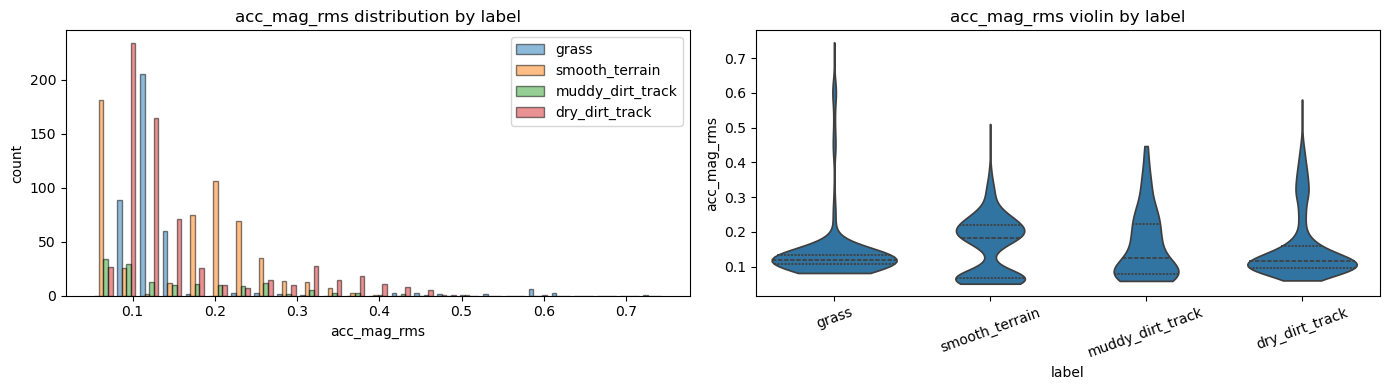

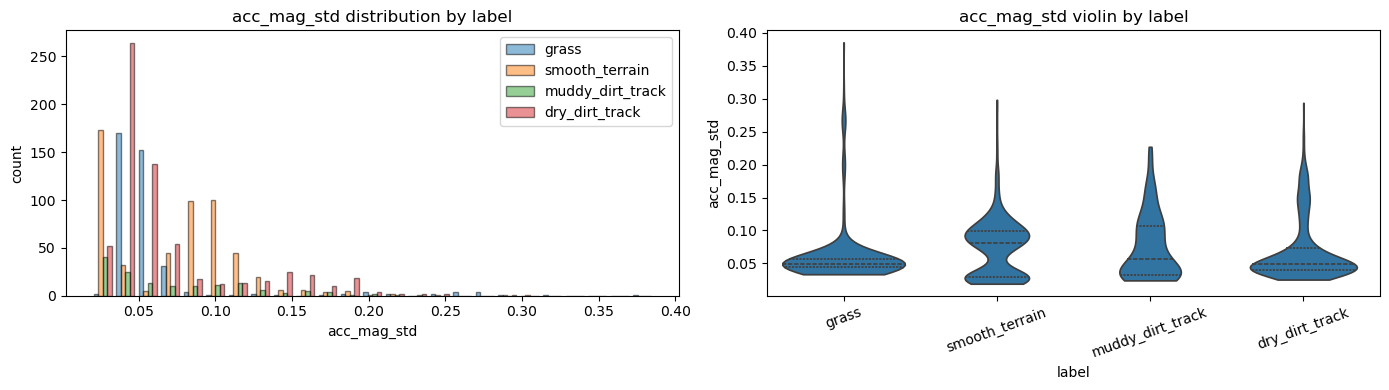

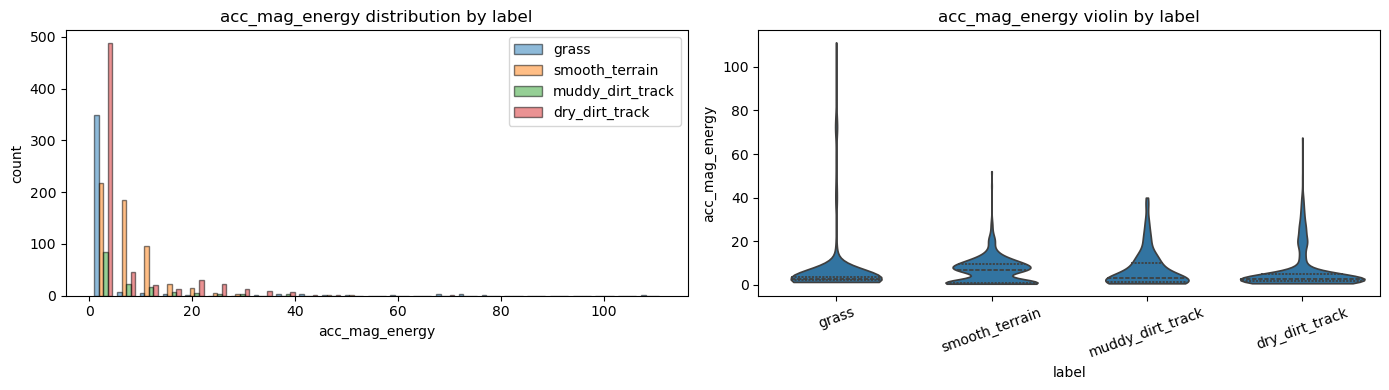

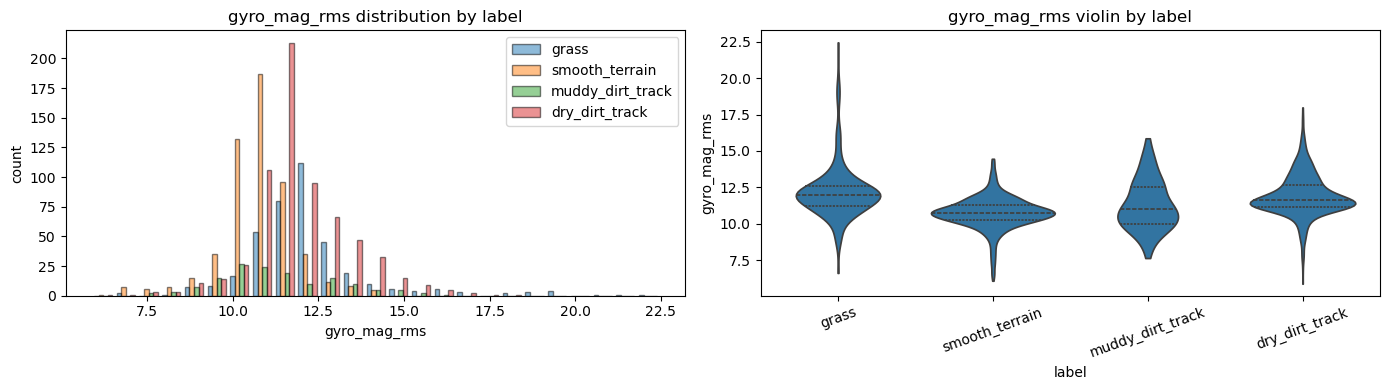

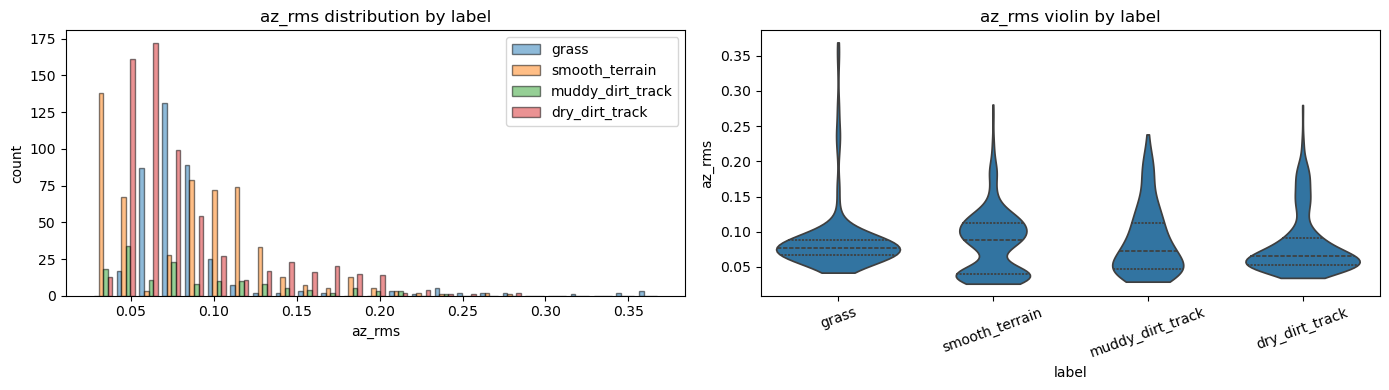

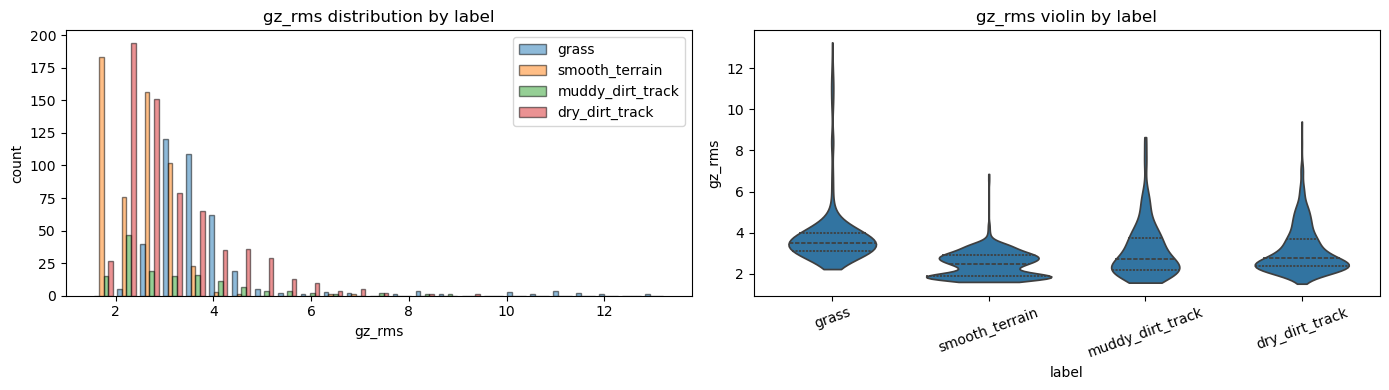

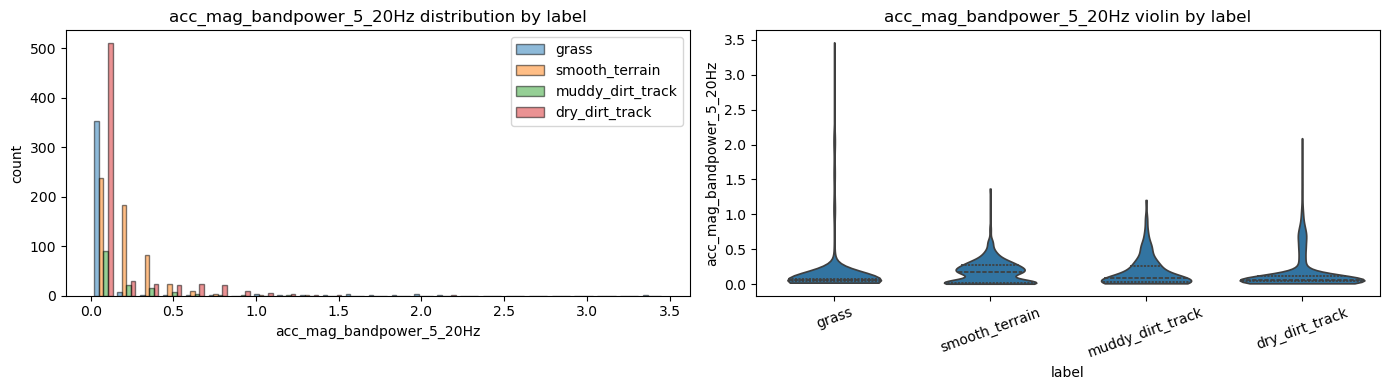

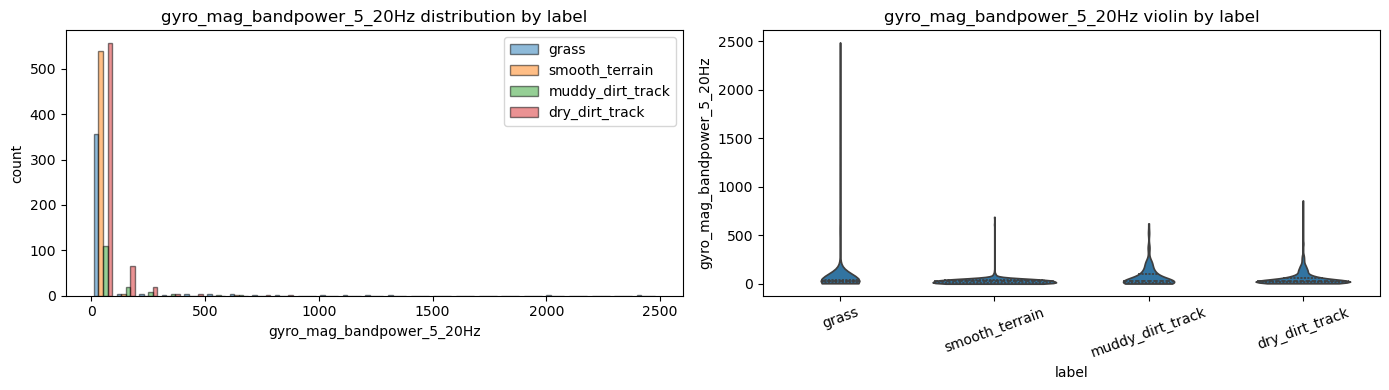

Saved 8 distribution figures to /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/reports/features/dataset_A


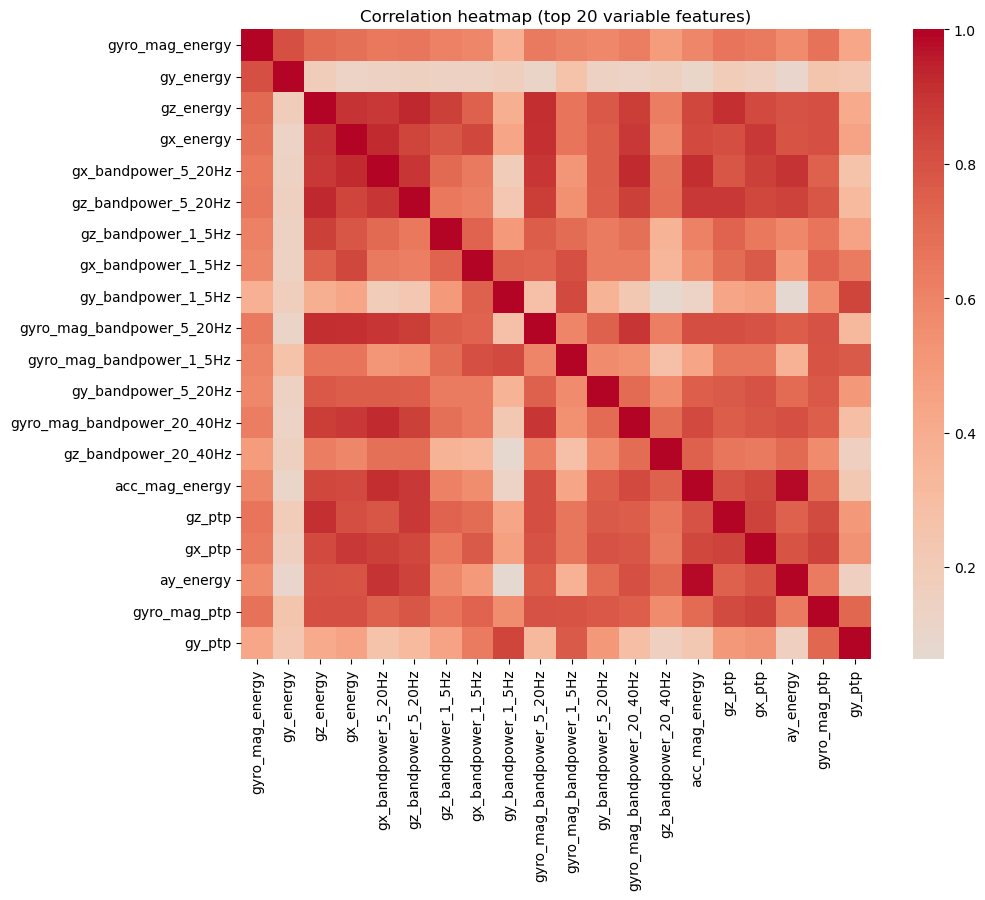

Top 15 absolute correlations among heatmap features:
                feature_1                  feature_2     corr
           acc_mag_energy                  ay_energy 0.981925
                gz_energy        gz_bandpower_5_20Hz 0.927686
                gx_energy        gx_bandpower_5_20Hz 0.925640
      gx_bandpower_5_20Hz gyro_mag_bandpower_20_40Hz 0.920962
      gx_bandpower_5_20Hz             acc_mag_energy 0.916222
                gz_energy  gyro_mag_bandpower_5_20Hz 0.912211
                gx_energy  gyro_mag_bandpower_5_20Hz 0.911382
                gz_energy                     gz_ptp 0.909031
                gz_energy                  gx_energy 0.900178
      gx_bandpower_5_20Hz                  ay_energy 0.898350
gyro_mag_bandpower_5_20Hz gyro_mag_bandpower_20_40Hz 0.896404
      gx_bandpower_5_20Hz  gyro_mag_bandpower_5_20Hz 0.895820
      gx_bandpower_5_20Hz        gz_bandpower_5_20Hz 0.890673
      gz_bandpower_5_20Hz                     gz_ptp 0.890182
                g

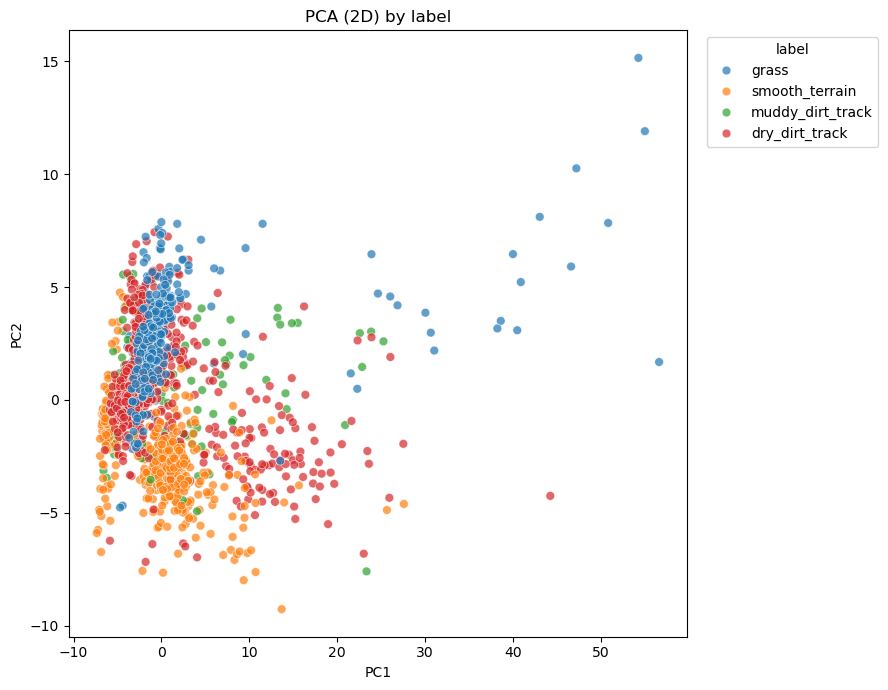

PCA explained variance ratio: [0.56607212 0.09650879]
PCA cumulative explained variance: 0.6625809082695993


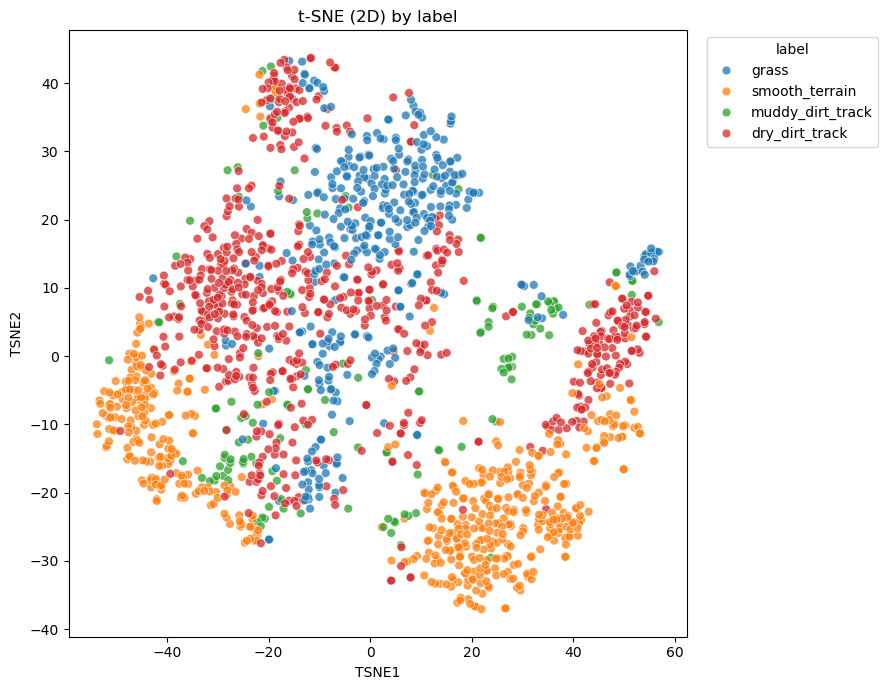

Saved PCA and t-SNE figures to: /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/reports/features/dataset_A
Evaluation completed.
Saved outputs to: /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/reports/features/dataset_A


In [3]:
# Run full evaluation pipeline (diagnostics + distributions + correlations + PCA/t-SNE)
eval_outputs = run_feature_evaluation(
    features_df=features_df,
    reports_dir=reports_dir,
    viz_features=viz_features,
    label_col='label',
    id_cols=id_cols,
    feature_cols=legacy_eval_feature_cols,
    top_n_heatmap=TOP_N_HEATMAP,
    random_state=RANDOM_STATE,
    tsne_sample_cap=TSNE_SAMPLE_CAP,
    show=True,
)

print('Evaluation completed.')
print(f"Saved outputs to: {reports_dir}")